<a href="https://colab.research.google.com/github/yassinemaataoui/Colab_project/blob/main/Atelier_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get update -qq && apt-get install -y openjdk-11-jdk
version = "3.5.7"
hadoop_version = "hadoop3"
url = f"https://downloads.apache.org/spark/spark-{version}/spark-{version}-bin-{hadoop_version}.tgz"
!wget {url} -O spark-{version}-bin-{hadoop_version}.tgz
!ls -lh spark-{version}-bin-{hadoop_version}.tgz
!tar -xvzf spark-{version}-bin-{hadoop_version}.tgz
!pip install -q findspark
import os, findspark
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = f"/content/spark-{version}-bin-{hadoop_version}"
findspark.init()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openjdk-11-jdk is already the newest version (11.0.28+6-1ubuntu1~22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 48 not upgraded.
--2025-11-15 20:47:18--  https://downloads.apache.org/spark/spark-3.5.7/spark-3.5.7-bin-hadoop3.tgz
Resolving downloads.apache.org (downloads.apache.org)... 135.181.214.104, 88.99.208.237, 2a01:4f8:10a:39da::2, ...
Connecting to downloads.apache.org (downloads.apache.org)|135.181.214.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 400914067 (382M) [application/x-gzip]
Saving to: ‘spark-3.5.7-bin-hadoop3.tgz’

spark-3.5.7-bin-had 100%[===================>] 382.34M  12.4MB/s    in 32s     

2025-11-15 20:47:51 (12.0 MB/s) - ‘spark-3.5.7-bin-

In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("Atelier_PySpark").getOrCreate()
spark

Partie 2 : Génération des données

In [ ]:
import pandas as pd
from random import randint, choice, uniform

regions = ["Casablanca", "Rabat", "Marrakech", "Fès", "Agadir"]
moyens = ["Bus", "Train", "Taxi", "Tram"]
data = [{
    "trajet_id": i,
    "region_depart": choice(regions),
    "region_arrivee": choice(regions),
    "distance_km": round(uniform(5, 600), 1),
    "duree_min": randint(10, 600),
    "nb_passagers": randint(1, 50),
    "revenu": round(uniform(50, 5000), 2),
    "moyen_transport": choice(moyens)
} for i in range(1000)]

df = pd.DataFrame(data)
df.to_csv("trajets.csv", index=False)
df_spark = spark.read.csv("trajets.csv", header=True, inferSchema=True)
df_spark.printSchema()
df_spark.show(5)

root
 |-- trajet_id: integer (nullable = true)
 |-- region_depart: string (nullable = true)
 |-- region_arrivee: string (nullable = true)
 |-- distance_km: double (nullable = true)
 |-- duree_min: integer (nullable = true)
 |-- nb_passagers: integer (nullable = true)
 |-- revenu: double (nullable = true)
 |-- moyen_transport: string (nullable = true)

+---------+-------------+--------------+-----------+---------+------------+-------+---------------+
|trajet_id|region_depart|region_arrivee|distance_km|duree_min|nb_passagers| revenu|moyen_transport|
+---------+-------------+--------------+-----------+---------+------------+-------+---------------+
|        0|   Casablanca|     Marrakech|       37.3|      105|          22|3986.57|           Tram|
|        1|        Rabat|        Agadir|      401.5|      597|          12|1193.23|          Train|
|        2|        Rabat|         Rabat|       36.2|       59|          35|4696.96|           Tram|
|        3|   Casablanca|        Agadir|      

Partie 3 : Nettoyage et enrichissement

In [ ]:
from pyspark.sql.functions import col, round as sround, when

df_clean = df_spark.filter(col("distance_km") > 0)
df_clean = df_clean.withColumn("revenu_par_km", sround(col("revenu")/col("distance_km"), 2))
df_clean = df_clean.withColumn("revenu_par_passager", sround(col("revenu")/col("nb_passagers"), 2))
df_clean = df_clean.withColumn(
    "categorie_distance",
    when(col("distance_km") <= 100, "Courte")
    .when(col("distance_km") <= 400, "Moyenne")
    .otherwise("Longue")
)
df_clean.show(5)

+---------+-------------+--------------+-----------+---------+------------+-------+---------------+-------------+-------------------+------------------+
|trajet_id|region_depart|region_arrivee|distance_km|duree_min|nb_passagers| revenu|moyen_transport|revenu_par_km|revenu_par_passager|categorie_distance|
+---------+-------------+--------------+-----------+---------+------------+-------+---------------+-------------+-------------------+------------------+
|        0|   Casablanca|     Marrakech|       37.3|      105|          22|3986.57|           Tram|       106.88|             181.21|            Courte|
|        1|        Rabat|        Agadir|      401.5|      597|          12|1193.23|          Train|         2.97|              99.44|            Longue|
|        2|        Rabat|         Rabat|       36.2|       59|          35|4696.96|           Tram|       129.75|              134.2|            Courte|
|        3|   Casablanca|        Agadir|      545.4|      460|           3|1713.26

Partie 4 : Analyse RDD

In [ ]:
rdd = df_clean.rdd
revenu_par_region = rdd.map(lambda x: (x["region_depart"], x["revenu"])) \
    .reduceByKey(lambda a,b: a+b) \
    .sortBy(lambda x: x[1], ascending=False)
revenu_par_region.take(5)

[('Marrakech', 500930.7999999998),
 ('Casablanca', 496760.9000000001),
 ('Rabat', 493284.51000000036),
 ('Fès', 473740.0299999999),
 ('Agadir', 452800.3)]

Partie 5 : Analyse SQL & DataFrame

In [ ]:
from pyspark.sql.functions import avg, sum as ssum, count

# revenu total par region
revenu_region = df_clean.groupBy("region_depart").agg(ssum("revenu").alias("revenu_total"))
revenu_region.show()

# revenu moyen et distance moyenne par transport
stats_transport = df_clean.groupBy("moyen_transport").agg(
    avg("revenu").alias("revenu_moyen"),
    avg("distance_km").alias("distance_moyenne"),
    count("*").alias("nb_trajets")
)
stats_transport.show()

df_clean.createOrReplaceTempView("trajets")
spark.sql("""
SELECT categorie_distance, AVG(revenu) AS revenu_moyen, COUNT(*) AS nb_trajets
FROM trajets GROUP BY categorie_distance
""").show()

+-------------+------------------+
|region_depart|      revenu_total|
+-------------+------------------+
|   Casablanca| 496760.9000000001|
|          Fès| 473740.0299999999|
|       Agadir|          452800.3|
|        Rabat|493284.51000000036|
|    Marrakech| 500930.7999999998|
+-------------+------------------+

+---------------+------------------+------------------+----------+
|moyen_transport|      revenu_moyen|  distance_moyenne|nb_trajets|
+---------------+------------------+------------------+----------+
|           Taxi| 2395.343373493975| 298.8674698795182|       249|
|           Tram|2355.7166086956527|288.63956521739135|       230|
|            Bus|2433.1687356321845|301.08927203065133|       261|
|          Train|2477.7083846153837|299.63692307692287|       260|
+---------------+------------------+------------------+----------+

+------------------+------------------+----------+
|categorie_distance|      revenu_moyen|nb_trajets|
+------------------+------------------+------

Partie 6 : Visualisation

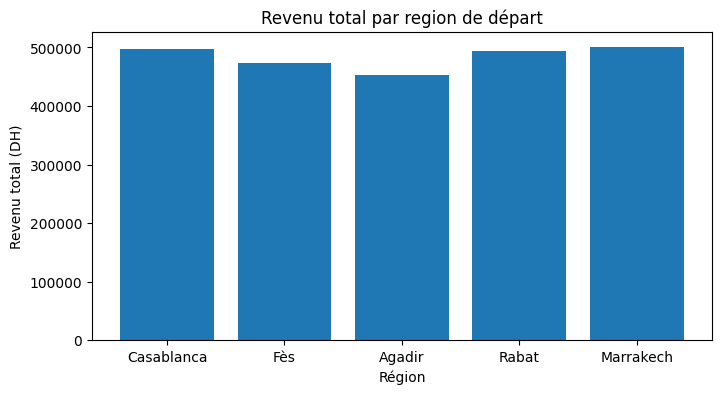

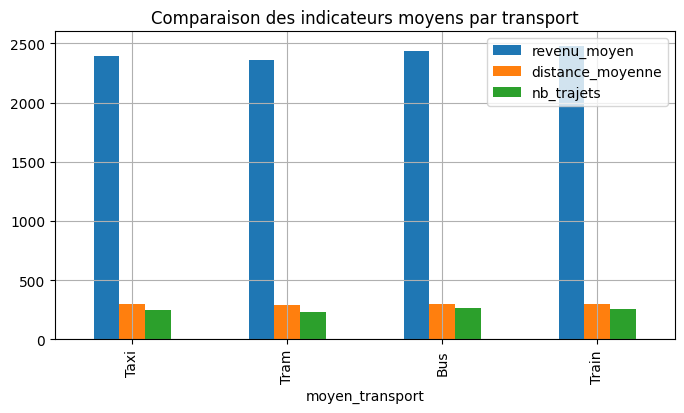

In [ ]:
#1. Conversion vers Pandas
pdf = revenu_region.toPandas()

#2. Graphique en barres
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(pdf["region_depart"], pdf["revenu_total"])
plt.title("Revenu total par region de départ")
plt.xlabel("Région")
plt.ylabel("Revenu total (DH)")
plt.show()

#3. Comparaison multi-indicateurs
pdf_stats = stats_transport.toPandas()
pdf_stats.plot(x="moyen_transport", kind="bar", figsize=(8,4))
plt.title("Comparaison des indicateurs moyens par transport")
plt.grid(True)
plt.show()

#parie *7*

1. Calculer le revenu moyen par région de départ

In [ ]:

df_clean.createOrReplaceTempView("trajets")
spark.sql("""
SELECT region_depart, AVG(revenu) AS revenu_moyen
FROM trajets
GROUP BY region_depart
""").show()

+-------------+------------------+
|region_depart|      revenu_moyen|
+-------------+------------------+
|   Casablanca|2388.2735576923083|
|          Fès|2467.3959895833327|
|       Agadir| 2501.659116022099|
|        Rabat|2294.3465581395367|
|    Marrakech| 2455.543137254901|
+-------------+------------------+



2. Calculer le nombre total de trajets par région d'arrivée

In [ ]:

spark.sql("""
SELECT region_arrivee, COUNT(*) AS nb_trajets
FROM trajets
GROUP BY region_arrivee
""").show()

+--------------+----------+
|region_arrivee|nb_trajets|
+--------------+----------+
|    Casablanca|       194|
|           Fès|       187|
|        Agadir|       213|
|         Rabat|       197|
|     Marrakech|       209|
+--------------+----------+



3. Trouver le revenu total et la distance moyenne par moyen de transport

In [ ]:

from pyspark.sql.functions import avg, sum as sum

df_clean.groupBy("moyen_transport").agg(
    sum("revenu").alias("revenu_total"),
    avg("distance_km").alias("distance_moyenne")
).show()

+---------------+-----------------+------------------+
|moyen_transport|     revenu_total|  distance_moyenne|
+---------------+-----------------+------------------+
|           Taxi|596440.4999999998| 298.8674698795182|
|           Tram|541814.8200000001|288.63956521739135|
|            Bus|635057.0400000002|301.08927203065133|
|          Train|644204.1799999998|299.63692307692287|
+---------------+-----------------+------------------+



4. Identifier la région de départ ayant le plus grand nombre de trajets

In [ ]:

spark.sql("""
SELECT region_depart, COUNT(*) AS nb_trajets
FROM trajets
GROUP BY region_depart
ORDER BY nb_trajets DESC
LIMIT 1
""").show()

+-------------+----------+
|region_depart|nb_trajets|
+-------------+----------+
|        Rabat|       215|
+-------------+----------+



5. Afficher les 3 trajets ayant la plus grande distance

In [ ]:
spark.sql("""
SELECT * FROM trajets
ORDER BY distance_km DESC
LIMIT 3
""").show()

+---------+-------------+--------------+-----------+---------+------------+-------+---------------+-------------+-------------------+------------------+
|trajet_id|region_depart|region_arrivee|distance_km|duree_min|nb_passagers| revenu|moyen_transport|revenu_par_km|revenu_par_passager|categorie_distance|
+---------+-------------+--------------+-----------+---------+------------+-------+---------------+-------------+-------------------+------------------+
|      299|          Fès|         Rabat|      597.3|      504|          37| 693.92|          Train|         1.16|              18.75|            Longue|
|      111|        Rabat|     Marrakech|      597.0|      232|           8|4963.36|            Bus|         8.31|             620.42|            Longue|
|      956|       Agadir|         Rabat|      596.7|      310|          42|1405.86|          Train|         2.36|              33.47|            Longue|
+---------+-------------+--------------+-----------+---------+------------+-------

6. Calculer le revenu moyen par catégorie de distance

In [ ]:
spark.sql("""
SELECT categorie_distance, AVG(revenu) AS revenu_moyen
FROM trajets
GROUP BY categorie_distance
""").show()

+------------------+------------------+
|categorie_distance|      revenu_moyen|
+------------------+------------------+
|            Longue|2405.5848765432092|
|            Courte| 2433.402307692308|
|           Moyenne|2419.4895141700426|
+------------------+------------------+



7. Déterminer la moyenne et la variance du revenu pour chaque région

In [ ]:
from pyspark.sql.functions import variance

df_clean.groupBy("region_depart").agg(
    avg("revenu").alias("revenu_moyen"),
    variance("revenu").alias("variance_revenu")
).show()

+-------------+------------------+------------------+
|region_depart|      revenu_moyen|   variance_revenu|
+-------------+------------------+------------------+
|   Casablanca|2388.2735576923083| 2223023.134080036|
|          Fès|2467.3959895833327|2093639.1017456122|
|       Agadir| 2501.659116022099|2049620.1756814364|
|        Rabat|2294.3465581395367| 2112863.052159127|
|    Marrakech| 2455.543137254901|  2033477.82766597|
+-------------+------------------+------------------+



8. Comparer le revenu moyen entre les différents moyens de transport

In [ ]:
spark.sql("""
SELECT moyen_transport, AVG(revenu) AS revenu_moyen
FROM trajets
GROUP BY moyen_transport
ORDER BY revenu_moyen DESC
""").show()

+---------------+------------------+
|moyen_transport|      revenu_moyen|
+---------------+------------------+
|          Train|2477.7083846153837|
|            Bus|2433.1687356321845|
|           Taxi| 2395.343373493975|
|           Tram|2355.7166086956527|
+---------------+------------------+



9. Calculer le nombre et le pourcentage de trajets par moyen de transport

In [ ]:
spark.sql("""
SELECT moyen_transport,
       COUNT(*) AS nb_trajets,
       (COUNT(*) * 100.0 / (SELECT COUNT(*) FROM trajets)) AS pourcentage
FROM trajets
GROUP BY moyen_transport
""").show()

+---------------+----------+-----------------+
|moyen_transport|nb_trajets|      pourcentage|
+---------------+----------+-----------------+
|           Taxi|       249|24.90000000000000|
|           Tram|       230|23.00000000000000|
|            Bus|       261|26.10000000000000|
|          Train|       260|26.00000000000000|
+---------------+----------+-----------------+



10. Identifier la région générant le revenu total le plus élevé

In [ ]:
spark.sql("""
SELECT region_depart, SUM(revenu) AS revenu_total
FROM trajets
GROUP BY region_depart
ORDER BY revenu_total DESC
LIMIT 1
""").show()

+-------------+-----------------+
|region_depart|     revenu_total|
+-------------+-----------------+
|    Marrakech|500930.7999999998|
+-------------+-----------------+



Visualisation

11. Graphique en barres - Revenu total par région de départ

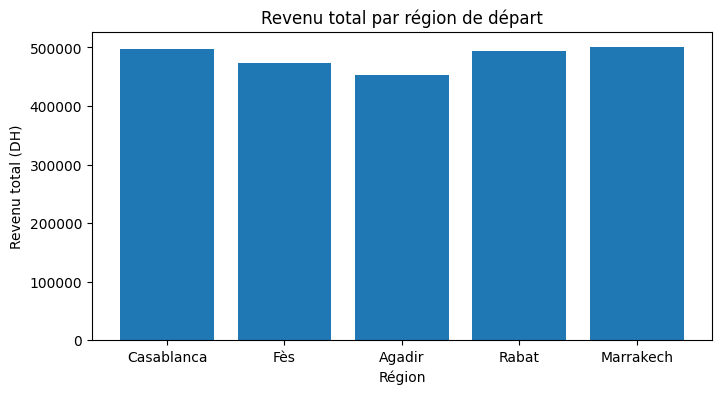

In [ ]:
# Conversion vers Pandas
pdf_revenu = revenu_region.toPandas()

# Graphique en barres
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(pdf_revenu["region_depart"], pdf_revenu["revenu_total"])
plt.title("Revenu total par région de départ")
plt.xlabel("Région")
plt.ylabel("Revenu total (DH)")
plt.show()

12. Graphique en barres - Revenu moyen par moyen de transport

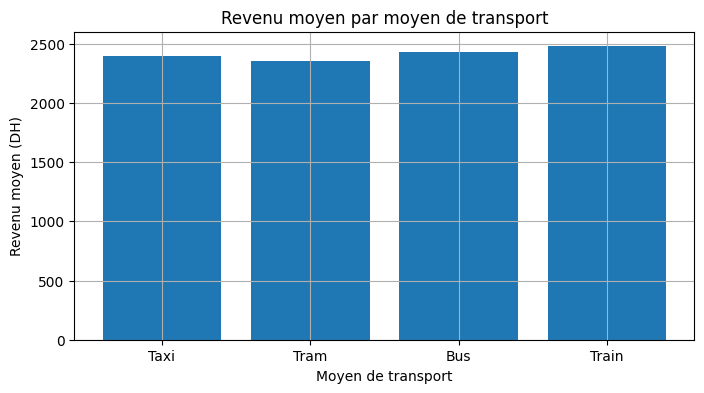

In [ ]:
# Calcul du revenu moyen par transport
revenu_moyen_transport = spark.sql("""
SELECT moyen_transport, AVG(revenu) AS revenu_moyen
FROM trajets
GROUP BY moyen_transport
""").toPandas()

# Graphique en barres
plt.figure(figsize=(8,4))
plt.bar(revenu_moyen_transport["moyen_transport"], revenu_moyen_transport["revenu_moyen"])
plt.title("Revenu moyen par moyen de transport")
plt.xlabel("Moyen de transport")
plt.ylabel("Revenu moyen (DH)")
plt.grid(True)
plt.show()